## **온라인 쇼핑몰 거래 데이터 분석 및 성과 대시보드 구축**
### **고객·상품·매출 데이터를 기반으로 한 이커머스 성과 분석 및 의사결정 지원**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("realistic_e_commerce_sales_data.csv")

In [3]:
df.head()

,Customer ID,Gender,Region,Age,Product Name,Category,Unit Price,Quantity,Total Price,Shipping Fee,Shipping Status,Order Date
0,CUST0268,Male,North,NaN,Monitor,Electronics,300.0,5,1500,13.31,Returned,2023-12-08
1,CUST0046,Male,West,22.0,Headphones,Accessories,100.0,2,200,6.93,In Transit,2023-04-09
2,CUST0169,Female,South,54.0,Monitor,Electronics,300.0,1,300,11.31,Returned,2023-08-28
3,CUST0002,Male,North,23.0,Headphones,Accessories,100.0,5,500,12.22,Delivered,2023-01-18
4,CUST0173,Female,South,NaN,Laptop,Electronics,1500.0,3,4500,5.40,Delivered,2023-01-19


In [4]:
df.shape

(1000, 12)

In [5]:
df.columns

Index(['Customer ID', 'Gender', 'Region', 'Age', 'Product Name', 'Category',
       'Unit Price', 'Quantity', 'Total Price', 'Shipping Fee',
       'Shipping Status', 'Order Date'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Customer ID      1000 non-null   object 
 1   Gender           1000 non-null   object 
 2   Region           950 non-null    object 
 3   Age              900 non-null    float64
 4   Product Name     1000 non-null   object 
 5   Category         1000 non-null   object 
 6   Unit Price       1000 non-null   float64
 7   Quantity         1000 non-null   int64  
 8   Total Price      1000 non-null   int64  
 9   Shipping Fee     1000 non-null   float64
 10  Shipping Status  950 non-null    object 
 11  Order Date       1000 non-null   object 
dtypes: float64(3), int64(2), object(7)
memory usage: 93.9+ KB


In [7]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
#날짜형으로 변환

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Customer ID      1000 non-null   object        
 1   Gender           1000 non-null   object        
 2   Region           950 non-null    object        
 3   Age              900 non-null    float64       
 4   Product Name     1000 non-null   object        
 5   Category         1000 non-null   object        
 6   Unit Price       1000 non-null   float64       
 7   Quantity         1000 non-null   int64         
 8   Total Price      1000 non-null   int64         
 9   Shipping Fee     1000 non-null   float64       
 10  Shipping Status  950 non-null    object        
 11  Order Date       1000 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(3), int64(2), object(6)
memory usage: 93.9+ KB


| 변수              | 의미       | 데이터 유형 | 분석 역할      |
| --------------- | -------- | ------ | ---------- |
| Customer ID     | 고객 식별자   | 범주형    | 고객 분석      |
| Gender          | 성별       | 범주형    | 고객 특성      |
| Region          | 지역       | 범주형    | 고객 특성      |
| Age             | 나이       | 수치형    | 고객 특성      |
| Product Name    | 상품명      | 범주형    | 상품 분석      |
| Category        | 상품 카테고리  | 범주형    | 상품 분석      |
| Unit Price      | 개별 상품 가격 | 수치형    | 가격 분석      |
| Quantity        | 구매 수량    | 수치형    | 구매 행동      |
| Total Price     | 총 구매금액   | 수치형    | **KPI** |
| Shipping Fee    | 배송비      | 수치형    | 비용         |
| Shipping Status | 배송 상태    | 범주형    | 배송         |
| Order Date      | 주문일      | 날짜형    | 시간 분석      |


### **null 값과 unique값을 함께 비교 분석**

In [9]:
df.isnull().sum()
#지역과 나이를 모르는 고객도 존재
#Shipping Status 도 50개 결측값 존재

Customer ID          0
Gender               0
Region              50
Age                100
Product Name         0
Category             0
Unit Price           0
Quantity             0
Total Price          0
Shipping Fee         0
Shipping Status     50
Order Date           0
dtype: int64

In [10]:
miss = pd.DataFrame({
    'null_count' : df.isnull().sum(),
    'null_ratio' : df.isnull().mean()*100})
miss[['null_ratio']]

,null_ratio
Customer ID,0.0
Gender,0.0
Region,5.0
Age,10.0
Product Name,0.0
Category,0.0
Unit Price,0.0
Quantity,0.0
Total Price,0.0
Shipping Fee,0.0


In [11]:
df.nunique()
#중복된 애들이 존재 (데이터 특성상 중복 데이터가 아닌 2번 주문한 것으로 간주)
#292명의 고객의 구매 데이터
#지역 4가지 
#물량은 5종류
#총 물건은 7가지 (3가지 Category)
# Unit Price가 총 물건 수를 넘는 것을 보아 한 Product Name에 여러 값이 부여될 수 있음을 시사
# 총 1000건 중 730개의 서로 다른 Shipping Fee

Customer ID        292
Gender               2
Region               4
Age                 52
Product Name         7
Category             3
Unit Price          13
Quantity             5
Total Price         26
Shipping Fee       730
Shipping Status      3
Order Date         340
dtype: int64

### **한 Product Name에 여러 값이 부여될 수 있음을 시사 -> 확인**

In [12]:
df[["Product Name", "Category", "Unit Price"]].drop_duplicates().sort_values("Product Name")
#한 Product Name에 여러 값이 부여될 수 있음을 시사 -> 확인

,Product Name,Category,Unit Price
1,Headphones,Accessories,100.000000
339,Headphones,Accessories,207.304041
7,Keyboard,Accessories,50.000000
84,Keyboard,Accessories,103.652020
4,Laptop,Electronics,1500.000000
560,Laptop,Electronics,3109.560612
0,Monitor,Electronics,300.000000
194,Monitor,Electronics,621.912122
8,Mouse,Accessories,30.000000
83,Mouse,Accessories,62.191212


In [13]:
df.groupby("Product Name")["Unit Price"].nunique()

Product Name
Headphones    2
Keyboard      2
Laptop        2
Monitor       2
Mouse         2
Smartphone    2
Smartwatch    1
Name: Unit Price, dtype: int64

### **특이한 Shipping Fee열 확인**
#### 배송비 : 5 ~ 19.8
#### 평균 배송비와 중앙값이 비슷 -> 골고루 퍼져있다
#### 50%의 배송비가 8.56 ~ 16.08 사이애 위치해있다.

In [14]:
df["Shipping Fee"].describe()

count    1000.000000
mean       12.416390
std         4.412185
min         5.000000
25%         8.560000
50%        12.315000
75%        16.075000
max        19.980000
Name: Shipping Fee, dtype: float64

In [15]:
df[["Shipping Fee"]].head()

,Shipping Fee
0,13.31
1,6.93
2,11.31
3,12.22
4,5.40


## **그렇다면 어떤 기준으로 배송비의 변동이 생기는 것일까 ??**
### Y = Shipping Fee
#### **1. 지역 Region**
#### **2. 카테고리 Category**
#### **3. 총 가격 Total Price**
#### **4. 물량 Quantity**
#### **5. 배송 상태 Shipping Status**

In [16]:
# 1. Region
df.groupby("Region")["Shipping Fee"].mean()

Region
East     12.316840
North    12.548515
South    12.399385
West     12.413984
Name: Shipping Fee, dtype: float64

In [17]:
df[["Region","Shipping Fee"]].sort_values("Region")

,Region,Shipping Fee
370,East,19.63
808,East,6.78
900,East,6.46
898,East,5.41
169,East,8.87
...,...,...
968,NaN,12.37
972,NaN,19.00
983,NaN,11.97
987,NaN,19.03


In [18]:
df.groupby("Region")["Shipping Fee"].agg(['mean','min','max'])
# => 큰 차이는 없는것 같다.

,mean,min,max
Region,,,
East,12.316840,5.00,19.84
North,12.548515,5.05,19.98
South,12.399385,5.02,19.94
West,12.413984,5.14,19.98


In [19]:
#2. Category
df.groupby("Category")["Shipping Fee"].agg(['mean','min','max'])

,mean,min,max
Category,,,
Accessories,12.198279,5.05,19.98
Electronics,12.615765,5.00,19.98
Wearables,12.353770,5.45,19.89


In [20]:
#3.Total Price
df.groupby("Total Price")['Shipping Fee'].agg(['mean','min','max'])
#가격이 상승한다고 해서 눈에 띠는 상승곡선을 그리지는 않는다.

,mean,min,max
Total Price,,,
30,11.204286,5.24,19.54
50,12.729583,5.56,19.41
60,11.971481,5.53,19.03
90,11.588750,5.07,19.41
100,11.983571,5.05,19.92
120,12.891739,5.17,19.59
150,11.830727,5.09,19.83
200,12.323222,5.13,19.81
250,12.117931,5.81,19.63


In [21]:
#4.Quantity
df.groupby("Quantity")["Shipping Fee"].agg(['mean','min','max'])

,mean,min,max
Quantity,,,
1,12.161015,5.16,19.84
2,12.157876,5.05,19.97
3,12.481321,5.00,19.98
4,12.614527,5.05,19.94
5,12.652995,5.02,19.98


**파생변수**

*Total Price = Unit Price * Quantity*

*Total Price는 Unit Price와 Quantity로 계산되는 파생변수*

*모든 행이 이 공식을 따르는지 확인*

In [22]:
df['calcu'] = df["Unit Price"] * df["Quantity"]
df['check'] = df['calcu'] == df['Total Price']
df['check'].value_counts()
# 공식에 따르지 않는 false 행 20개 발견

True     980
False     20
Name: check, dtype: int64

In [23]:
df.loc[df['check'] == False, ['Product Name', 'Category','Unit Price','Quantity', 'Total Price']]

,Product Name,Category,Unit Price,Quantity,Total Price
26,Smartphone,Electronics,1658.432327,2,1600
83,Mouse,Accessories,62.191212,2,60
84,Keyboard,Accessories,103.652020,4,200
110,Mouse,Accessories,62.191212,2,60
194,Monitor,Electronics,621.912122,5,1500
209,Monitor,Electronics,621.912122,5,1500
215,Mouse,Accessories,62.191212,1,30
226,Keyboard,Accessories,103.652020,4,200
244,Monitor,Electronics,621.912122,3,900
339,Headphones,Accessories,207.304041,1,100


In [24]:
df['cal unit'] = df['Total Price'] / df['Quantity']
df[['Category', 'Unit Price','cal unit']].drop_duplicates().sort_values("Category")

,Category,Unit Price,cal unit
1,Accessories,100.000000,100.0
7,Accessories,50.000000,50.0
8,Accessories,30.000000,30.0
83,Accessories,62.191212,30.0
84,Accessories,103.652020,50.0
339,Accessories,207.304041,100.0
0,Electronics,300.000000,300.0
4,Electronics,1500.000000,1500.0
17,Electronics,800.000000,800.0
26,Electronics,1658.432327,800.0


### **데이터 품질 오류 발견**
정상 : (실제 단가) unit price = total price / quantity 

오류 : unit price = (실제 단가) * 2

=> 따라서 Unit Price 를 수정

In [25]:
df['Final_unit_price'] = df['Total Price']/df['Quantity']

### **각 열의 분포 확인**

In [26]:
df.describe()
#Unit Price는 min max 차이가 엄청 남
#Age 35세 이상으로 주로 이루어져있다.

,Age,Unit Price,Quantity,Total Price,Shipping Fee,calcu,cal unit,Final_unit_price
count,900.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,46.695556,457.703777,3.008000,1346.600000,12.416390,1378.791212,446.630000,446.630000
std,15.011400,537.231434,1.404246,1834.037877,4.412185,1917.117091,510.898777,510.898777
min,18.000000,30.000000,1.000000,30.000000,5.000000,30.000000,30.000000,30.000000
25%,35.000000,50.000000,2.000000,200.000000,8.560000,200.000000,50.000000,50.000000
50%,49.000000,200.000000,3.000000,600.000000,12.315000,600.000000,200.000000,200.000000
75%,59.000000,800.000000,4.000000,1500.000000,16.075000,1500.000000,800.000000,800.000000
max,69.000000,3109.560612,5.000000,7500.000000,19.980000,15547.803062,1500.000000,1500.000000


### **Ecommerece KPI 생성**

In [27]:
#매출 합계
df[['Total Price']].sum()

Total Price    1346600
dtype: int64

In [28]:
# 총 주문 건수
len(df)

1000

In [29]:
#고객 합계
df[['Customer ID']].nunique()

Customer ID    292
dtype: int64

In [30]:
#평균 주문 금액
df[['Total Price']].mean()

Total Price    1346.6
dtype: float64

In [31]:
#한 고객 당 평균 주문 행태 
df.groupby('Customer ID')[['Total Price']].describe()

Total Price                                                   \
                  count         mean          std    min     25%     50%   
Customer ID                                                                
CUST0001            2.0  3075.000000  4136.574670  150.0  1612.5  3075.0   
CUST0002            3.0   516.666667   275.378527  250.0   375.0   500.0   
CUST0003            3.0  1630.000000  2082.954632   90.0   445.0   800.0   
CUST0004            5.0  1300.000000  1572.020992  150.0   250.0   900.0   
CUST0005            1.0    60.000000          NaN   60.0    60.0    60.0   
...                 ...          ...          ...    ...     ...     ...   
CUST0296            6.0  1188.333333  1504.532042   30.0   150.0   750.0   
CUST0297            2.0   600.000000     0.000000  600.0   600.0   600.0   
CUST0298            4.0  1355.000000  1380.857222  120.0   405.0  1050.0   
CUST0299            7.0  1437.142857  1770.402160   60.0   300.0   600.0   
CUST0300            2.0   445.000000   502.045815   90.0   267.5   445.0   

                             
                75%     max  
Customer ID                  
CUST0001     4537.5  6000.0  
CUST0002      650.0   800.0  
CUST0003     2400.0  4000.0  
CUST0004     1200.0  4000.0  
CUST0005       60.0    60.0  
...             ...     ...  
CUST0296     1425.0  4000.0  
CUST0297      600.0   600.0  
CUST0298     2000.0  3200.0  
CUST0299     2400.0  4000.0  
CUST0300      622.5   800.0  

[292 rows x 8 columns]

**고객 관리 테이블은 서로 다른 점이 많기 때문에 따로 df를 만들겟다.**

In [32]:
customer_df = df.groupby('Customer ID').agg(
    purchase_count = ('Total Price','count'), #고객별 구매 횟수
    purchase_sum = ('Total Price','sum'), #고객별 총 구매금액
    mean_price = ('Total Price','mean'), #고객별 평균 주문 금액
    product_count = ('Product Name', 'nunique')) #고객별 구매 상품 종
customer_df.head(10)

,purchase_count,purchase_sum,mean_price,product_count
Customer ID,,,,
CUST0001,2,6150,3075.000000,2
CUST0002,3,1550,516.666667,3
CUST0003,3,4890,1630.000000,3
CUST0004,5,6500,1300.000000,3
CUST0005,1,60,60.000000,1
CUST0006,6,10400,1733.333333,4
CUST0007,3,1100,366.666667,2
CUST0008,4,1370,342.500000,4
CUST0009,1,200,200.000000,1


1번 고객과 4번 고객의 구매 총합은 비슷하지만

1번은 고액 제품 단발 구매 고객이고
4번은 소액 제품 반복 구매 고객이다.

In [33]:
customer_df.loc[["CUST0001","CUST0004"]]

,purchase_count,purchase_sum,mean_price,product_count
Customer ID,,,,
CUST0001,2,6150,3075.0,2
CUST0004,5,6500,1300.0,3


In [34]:
customer_df.loc[["CUST0002","CUST0003"]]

,purchase_count,purchase_sum,mean_price,product_count
Customer ID,,,,
CUST0002,3,1550,516.666667,3
CUST0003,3,4890,1630.000000,3


In [35]:
customer_df.describe()

,purchase_count,purchase_sum,mean_price,product_count
count,292.000000,292.000000,292.000000,292.000000
mean,3.424658,4611.643836,1306.449242,2.780822
std,1.783219,4270.680033,1107.481608,1.257244
min,1.000000,60.000000,30.000000,1.000000
25%,2.000000,1295.000000,515.500000,2.000000
50%,3.000000,3595.000000,945.714286,3.000000
75%,5.000000,6592.500000,1822.142857,4.000000
max,9.000000,29100.000000,6000.000000,6.000000


In [36]:
customer_df['mean_price'].describe()
# std  -> 편차가 상당히 크다.|

count     292.000000
mean     1306.449242
std      1107.481608
min        30.000000
25%       515.500000
50%       945.714286
75%      1822.142857
max      6000.000000
Name: mean_price, dtype: float64

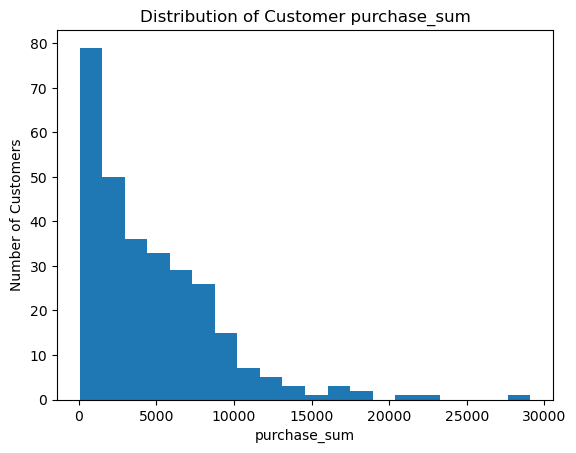

In [37]:
plt.hist(customer_df['purchase_sum'], bins=20)
plt.xlabel('purchase_sum')
plt.ylabel('Number of Customers')
plt.title('Distribution of Customer purchase_sum')
plt.show()
#대부분의 고객은 낮은 금액에 몰려있고 15,000 이상 고객은 소수이다.

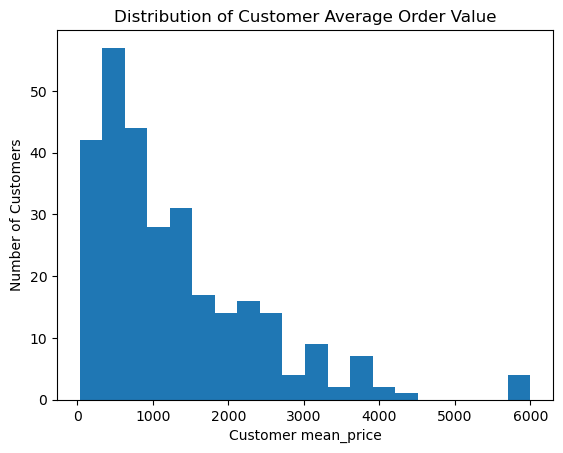

In [38]:
plt.hist(customer_df['mean_price'], bins=20)
plt.xlabel('Customer mean_price')
plt.ylabel('Number of Customers')
plt.title('Distribution of Customer Average Order Value')
plt.show()

### 평균 주문 금액(mean_purchase)와 구매 총액(purchase_sum)을 보아하니 mean 과 중앙값의 차이가 많이 남 

### -> 고액 주문 고객이 평균을 끌어올리고 있음
# **중앙값을 쓰는 선택을 하겠음**

| 지표      |    평균 |   중앙값 | 판단          |
| ------- | ----: | ----: | ----------- |
| 구매횟수    |  3.42 |     3 | 평균 사용 가능    |
| 총 구매금액  | 4,611 | 3,595 | **중앙값도 중요** |
| 평균 주문금액 | 1,306 |   946 | **중앙값도 중요** |
| 상품 종류   |  2.78 |     3 | 평균 사용 가능    |


**구매 횟수(purchase_count)가 똑같아도 총 구매금액 (purchase_sum)이 차이가 많이 나거나**
**총 구매금액 (purchase_sum)이 같아도 1회 평균 주문금액(mean_price)가 차이가 많이 난다.**

**고객마다 구매 행동이 상당히 다르다. -> mean_price로 고객을 설명하기에는 부족**
**=>고객을 전체로 보는 것이 아닌 고객군으로 나눠보자**

### **1. "그렇다면 어떤 고객이 높은 구매금액을 만들어내고 있는가?"**
**먼저 purchase_count와 purchase_sum 간의 관계를 보자**

왜냐면 자주 구매하는 것은 무조건 높은 구매금액을 만들어내는지 확인할 필요가 있다.

In [39]:
customer_df[
    ['purchase_count', 'purchase_sum', 'mean_price', 'product_count']
].corr()

,purchase_count,purchase_sum,mean_price,product_count
purchase_count,1.000000,0.633405,0.069865,0.883160
purchase_sum,0.633405,1.000000,0.676409,0.514800
mean_price,0.069865,0.676409,1.000000,0.044834
product_count,0.883160,0.514800,0.044834,1.000000


**purchase_count <-> mean_price ~ 0  => 자주 구매하는 고객이라고 한번 구매할 때 많은 금액을 쓰는 것은 아니다. / 구매 횟수가 적어도 한번에 많은 금액을 소비하는 고객도 있다**

**mean_price <-> purchase_sum = 0.676 ~> 둘은 수학적으로 연결되기 때문에 상관관계 높을 수 밖에 없음**

**purchase_count <-> product_count = 0.883 ~> 여러번 구매한 고객일수록 여러가지 제품을 구매하는 경향이 있다.**

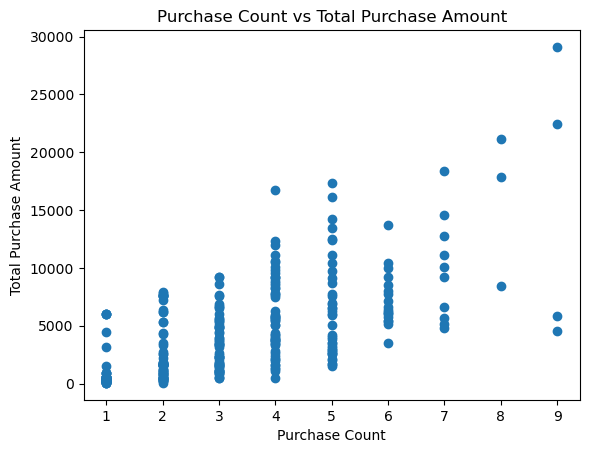

In [40]:
plt.scatter(
    customer_df['purchase_count'],
    customer_df['purchase_sum']
)

plt.xlabel('Purchase Count')
plt.ylabel('Total Purchase Amount')
plt.title('Purchase Count vs Total Purchase Amount')
plt.show()

### purchase_count와 purchase sum이 어느정도 양의 상관관계를 보인다. (상관계수 = 0.633)
**구매 횟수가 같아도 구매 가격의 차이가 상당히 크다.**

**->구매 횟수는 총 구매금액과 관련이 있지만, 구매 횟수만으로 고객의 구매금액을 설명할 수는 없다.**

**그렇다면 높은 purchase sum 은 구매 빈도 때문일까 아니면 한번에 많은 금액을 쓰기 때문일까**

1. 자주 구매하지만 한 번 살 때 적게 구매  => 교차판매 / 묶음상품 / 객단가 상승
2. 자주 구매하진 않지만 한번 살 때 많이 구매 => 재구매 유도
3. 자주 구매하고 많이 구매 => 핵심 고객 / VIP 관

In [41]:
# 1. 구매횟수 분위수 파악 / 평균 주문 금액 분위수 파악 
print('구매횟수 분위수')
print(customer_df['purchase_count'].quantile([0.25, 0.5, 0.75]))
print('\n구매횟수 중앙값')
print(customer_df['purchase_count'].mean())

print("------------------------------------------------------")

print('평균 주문금액 분위수')
print(customer_df['mean_price'].quantile([0.25, 0.5, 0.75]))
print('\n평균 주문금액 중앙값')
print(customer_df['mean_price'].mean())

구매횟수 분위수
0.25    2.0
0.50    3.0
0.75    5.0
Name: purchase_count, dtype: float64

구매횟수 중앙값
3.4246575342465753
------------------------------------------------------
평균 주문금액 분위수
0.25     515.500000
0.50     945.714286
0.75    1822.142857
Name: mean_price, dtype: float64

평균 주문금액 중앙값
1306.4492416829746


### **고객 세그먼트 만들기**

In [42]:
count_threshold = customer_df['purchase_count'].quantile(0.75) #구매횟수 기준
aov_threshold = customer_df['mean_price'].quantile(0.75) # 평균가 기준 

customer_df['frequency_segment'] = np.where(
    customer_df['purchase_count'] >= count_threshold,
    'High Frequency',
    'Low Frequency'
)

customer_df['aov_segment'] = np.where(
    customer_df['mean_price'] >= aov_threshold,
    'High AOV',
    'Low AOV'
)
customer_df['customer_segment'] = (
    customer_df['frequency_segment'] + ' + ' +
    customer_df['aov_segment']
)
customer_df['customer_segment'].value_counts()

Low Frequency + Low AOV      163
High Frequency + Low AOV      56
Low Frequency + High AOV      55
High Frequency + High AOV     18
Name: customer_segment, dtype: int64

In [43]:
customer_df['customer_segment']

Customer ID
CUST0001    Low Frequency + High AOV
CUST0002     Low Frequency + Low AOV
CUST0003     Low Frequency + Low AOV
CUST0004    High Frequency + Low AOV
CUST0005     Low Frequency + Low AOV
                      ...           
CUST0296    High Frequency + Low AOV
CUST0297     Low Frequency + Low AOV
CUST0298     Low Frequency + Low AOV
CUST0299    High Frequency + Low AOV
CUST0300     Low Frequency + Low AOV
Name: customer_segment, Length: 292, dtype: object

In [44]:
# 4개의 고객군이 어떤 특징들이 있나 비교 (고객군 별로 고객수, 매출 금액, 고객당 구매금액, 상품 다양성)
customer_df.groupby('customer_segment').agg(
    c_count = ("purchase_sum",'count'), #고객 수 
    total_sum = ('purchase_sum', 'sum'), #매출 금액 
    c_meansum = ('purchase_sum','mean'), #고객 1명당 구매 금액평균 
    product_count = ('product_count','mean')) #구매 한번 할 때 사는 상풉 수 


,c_count,total_sum,c_meansum,product_count
customer_segment,,,,
High Frequency + High AOV,18,276580,15365.555556,4.111111
High Frequency + Low AOV,56,313740,5602.500000,4.125000
Low Frequency + High AOV,55,428340,7788.000000,2.509091
Low Frequency + Low AOV,163,327940,2011.901840,2.263804


**1. low + low 가 고객 수는 가장 많고 그 다음으로 낮은빈도 + 높은 가격 , 잦은 빈도 + 낮은 금액이 뒤따랐다.**

**2. total_sum이 low frequency + high aov가 가장 높다 -> 결국 VIP 고객군은 낮은 구매 빈도지만 한번에 높은 가격의 구매를 하는 고객들이다. 고객 수는 중간 정도로 많은데 한 번 구매할 때 높은 금액을 쓰기 때문에 총 매출이 가장 많이 나왓다.  / High Frequency + High AOV의 매출이 제일 높을 줄 알았지만 고객 수 자체가 적어버려서 총 매출이 제일 적게 나왔다. 그러나 1인당 구매 금액 평균이 가장 높고 상품의 다양성 또한 높기 때문에 고빈도.고객단가 그룹이라고 칭할 수 있다.**

**3. 앞 전에 purchase_count 와 product_count의 강한 양의 상관관계를 보여주는 결과. high frequenct일수록 product_count 는 높다.**

# **상품 분석**

In [52]:
df.groupby('Category')['Final_unit_price'].mean()

Category
Accessories     58.179551
Electronics    836.268344
Wearables      200.000000
Name: Final_unit_price, dtype: float64

In [57]:
df.groupby('Category').agg(
    total_sales=('Total Price', 'sum'), # 총매출
    order_count=('Total Price', 'count'), # 주문 건수 (중복 고객 포함)
    avg_order_mean=('Total Price', 'mean'), # 주문 1개당 평균 금액
    product_avg = ('Quantity', 'mean'), # 한 번 주문할 때 주문하는 제품 개수 평균
    customer_count=('Customer ID', 'nunique'), # 주문한 고객 
)

,total_sales,order_count,avg_order_mean,product_avg,customer_count
Category,,,,,
Accessories,71900,401,179.301746,3.062344,228
Electronics,1200500,477,2516.771488,2.953878,235
Wearables,74200,122,608.196721,3.040984,103


**1. Electronics가 압도적으로 큰 매출 -> elextronics 상품의 개별 가격이 애초에 높고 주문 건수도 가장 많다.**

**Electronics: 고객 235명, 주문 477건, 평균 주문금액 2,516.8, 주문 한 건당 상품 개수 평균 : 2.95
Accessories: 고객 228명, 주문 401건, 평균 주문금액 179.3, 주문 한 건당 상품 개수 평균 : 3.06**

**이렇게 electronics과 accessories 는 고객 수 , 주문 건수, 주문 한 건당 상품 개수는 비슷하지만 unit_price에서 약 14.36배의 큰 차이가 있어 주문금액 차이가 많이 난다.**

**wearables은 accessories 보다 주문 건수가 훨씬 적지만 unit_price도 약 3.5배정도 커서 한 건당 상품 개수가 3개정도로 비슷해도 주문 평균 금액에서 3배가량 더 큰 형상을 보였다. 이에 따라 총 매출은 74,200 / 71,900 으로 나타났다.**

### **그럼 어떤 상품이 매출을 주로 이루고 있나 +**
### **Electronics 매출이 높은게 어떤 특정 상품 때문인지 확인**

In [86]:
product_df = df.groupby(['Category','Product Name']).agg(
    total_sales=('Total Price', 'sum'), #총 매출
    order_count=('Total Price', 'count'), #주문 건수
    avg_product_value=('Final_unit_price', 'mean'), #상품 1개당 평균 금액 
    customer_count=('Customer ID', 'nunique') #고객 수
).reset_index()

In [87]:
product_df.sort_values('total_sales', ascending=False)

,Category,Product Name,total_sales,order_count,avg_product_value,customer_count
3,Electronics,Laptop,696000,154,1500.0,121
5,Electronics,Smartphone,353600,142,800.0,112
4,Electronics,Monitor,150900,181,300.0,135
6,Wearables,Smartwatch,74200,122,200.0,103
0,Accessories,Headphones,37000,120,100.0,103
1,Accessories,Keyboard,22900,145,50.0,121
2,Accessories,Mouse,12000,136,30.0,117


**Electronics의 높은 매출에는 Laptop의 높은 단가가 크게 기여**

**Monitor는 주문 횟수는 가장 많지만 단가가 Laptop에 약 1/5**

### **주문 건수만으로 매출 규모가 결정되는 건 아니고, 상품 단가의 영향도 크다**
### **Keyboard와 Mouse는 주문횟수는 많지만 매출이 최하위 2개 -> 단가가 너무 낮다. -> 그치만 주문을 많이 하니까 묶음 상품으로 팔기 좋다.**

## **=>상품별 매출은 주문 건수뿐만 아니라 상품 단가의 영향을 크게 받았다. 특히 Laptop은 주문 건수가 Monitor보다 적음에도 높은 단가로 가장 높은 매출을 기록했다. 반면 Accessories는 상대적으로 낮은 단가로 주문 건수에 비해 매출 기여도가 낮았다.**

# **시간에 따른 매출 변화**

In [89]:
month_df = df.groupby(df['Order Date'].dt.to_period('M')).agg(
    total_sales=('Total Price', 'sum'),
    order_count=('Total Price', 'count'),
    avg_order_mean = ('Total Price','mean') # 주문 하나가 튈 수 있으니까
).reset_index()

In [90]:
month_df

,Order Date,total_sales,order_count,avg_order_mean
0,2023-01,141360,94,1503.829787
1,2023-02,78910,74,1066.351351
2,2023-03,67660,67,1009.850746
3,2023-04,87840,66,1330.909091
4,2023-05,120080,86,1396.279070
5,2023-06,129450,90,1438.333333
6,2023-07,103160,79,1305.822785
7,2023-08,108050,84,1286.309524
8,2023-09,119490,81,1475.185185
9,2023-10,118240,91,1299.340659


## (이건 음 애매)연말 연초에 매출이 증가하는 형태를 띄었다.
### 2023년 11월이 최고 매출 (주문 평균 금액, 주문건수 둘 다 높음)

* 2024-01 매출이 현저히 적은 것은 1월 전체 데이터가 적은 것 같다

# **<span style="color: purple;">분석 테이블 정리</span>**

### **<span style="color: green;"> 고객 segmemt</span>**

In [65]:
customer_segment_df = customer_df.copy()

customer_segment_df.head()

,purchase_count,purchase_sum,mean_price,product_count,frequency_segment,aov_segment,customer_segment
Customer ID,,,,,,,
CUST0001,2,6150,3075.000000,2,Low Frequency,High AOV,Low Frequency + High AOV
CUST0002,3,1550,516.666667,3,Low Frequency,Low AOV,Low Frequency + Low AOV
CUST0003,3,4890,1630.000000,3,Low Frequency,Low AOV,Low Frequency + Low AOV
CUST0004,5,6500,1300.000000,3,High Frequency,Low AOV,High Frequency + Low AOV
CUST0005,1,60,60.000000,1,Low Frequency,Low AOV,Low Frequency + Low AOV


### **<span style="color: green;"> 카테고리 & 상품</span>**

In [88]:
product_df 

,Category,Product Name,total_sales,order_count,avg_product_value,customer_count
0,Accessories,Headphones,37000,120,100.0,103
1,Accessories,Keyboard,22900,145,50.0,121
2,Accessories,Mouse,12000,136,30.0,117
3,Electronics,Laptop,696000,154,1500.0,121
4,Electronics,Monitor,150900,181,300.0,135
5,Electronics,Smartphone,353600,142,800.0,112
6,Wearables,Smartwatch,74200,122,200.0,103


### **<span style="color: green;"> 웗</span>**

In [91]:
month_df

,Order Date,total_sales,order_count,avg_order_mean
0,2023-01,141360,94,1503.829787
1,2023-02,78910,74,1066.351351
2,2023-03,67660,67,1009.850746
3,2023-04,87840,66,1330.909091
4,2023-05,120080,86,1396.279070
5,2023-06,129450,90,1438.333333
6,2023-07,103160,79,1305.822785
7,2023-08,108050,84,1286.309524
8,2023-09,119490,81,1475.185185
9,2023-10,118240,91,1299.340659


In [80]:
customer_segment_df.to_csv('customer_segment.csv', index=False)

In [92]:
product_df.to_csv('product.csv', index=False)

In [93]:
month_df.to_csv('month_sales.csv', index=False)